In [9]:
!pip install -q xgboost shap

In [10]:
from google.colab import drive
drive.mount("/content/drive")
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

file_path = "/content/drive/MyDrive/Colab Notebooks/DATA6520/hr_data.csv"
df = pd.read_csv(file_path)

X = df.drop(columns=["left"]).copy()
y = df["left"].copy()

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# Force all columns to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Replace any missing values created during coercion
X = X.fillna(0)

# Convert booleans to integers if any remain
for col in X.columns:
    if X[col].dtype == "bool":
        X[col] = X[col].astype(int)

# Final numeric type for model + SHAP
X = X.astype(float)
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.dtypes.value_counts())
print("Any object columns left?", (X_train.dtypes == "object").any())
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
float64    18
Name: count, dtype: int64
Any object columns left? False
X_train shape: (11999, 18)
X_test shape: (3000, 18)


In [11]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [12]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9777
Precision: 0.9695
Recall: 0.9356
F1 Score: 0.9522
ROC AUC: 0.9927

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2286
           1       0.97      0.94      0.95       714

    accuracy                           0.98      3000
   macro avg       0.97      0.96      0.97      3000
weighted avg       0.98      0.98      0.98      3000

Confusion Matrix:
[[2265   21]
 [  46  668]]


In [13]:
import shap

explainer = shap.Explainer(model, X_train.astype(float))
shap_values = explainer(X_test.astype(float))

 95%|=================== | 2860/3000 [00:38<00:01]       

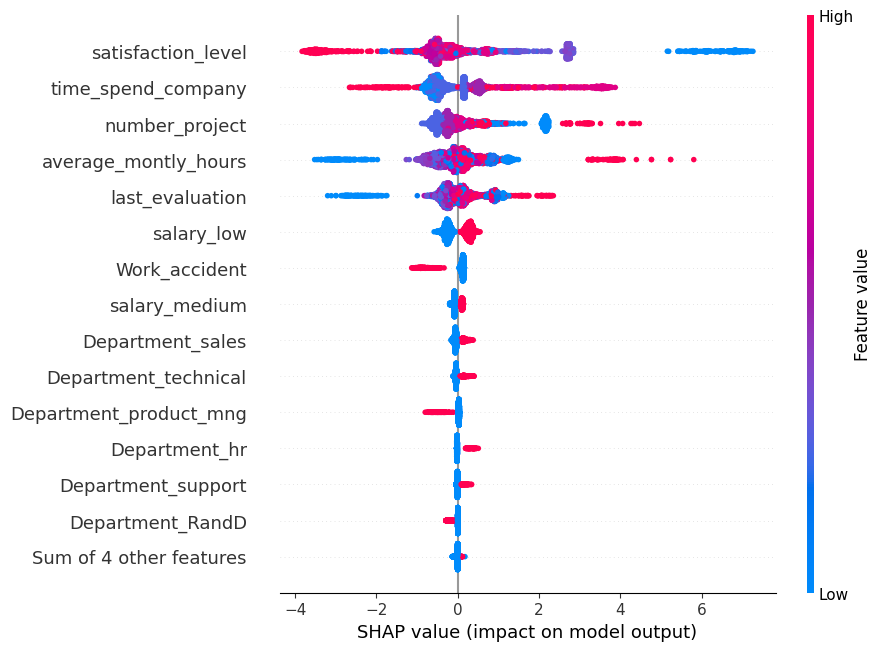

In [14]:
shap.plots.beeswarm(shap_values, max_display=15)

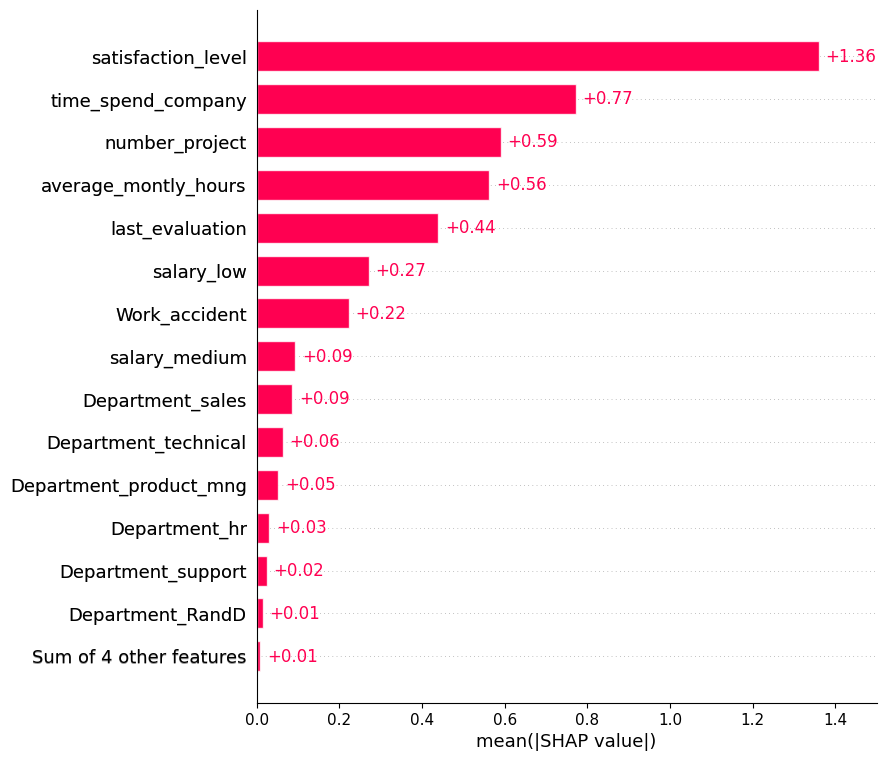

In [15]:
shap.plots.bar(shap_values, max_display=15)

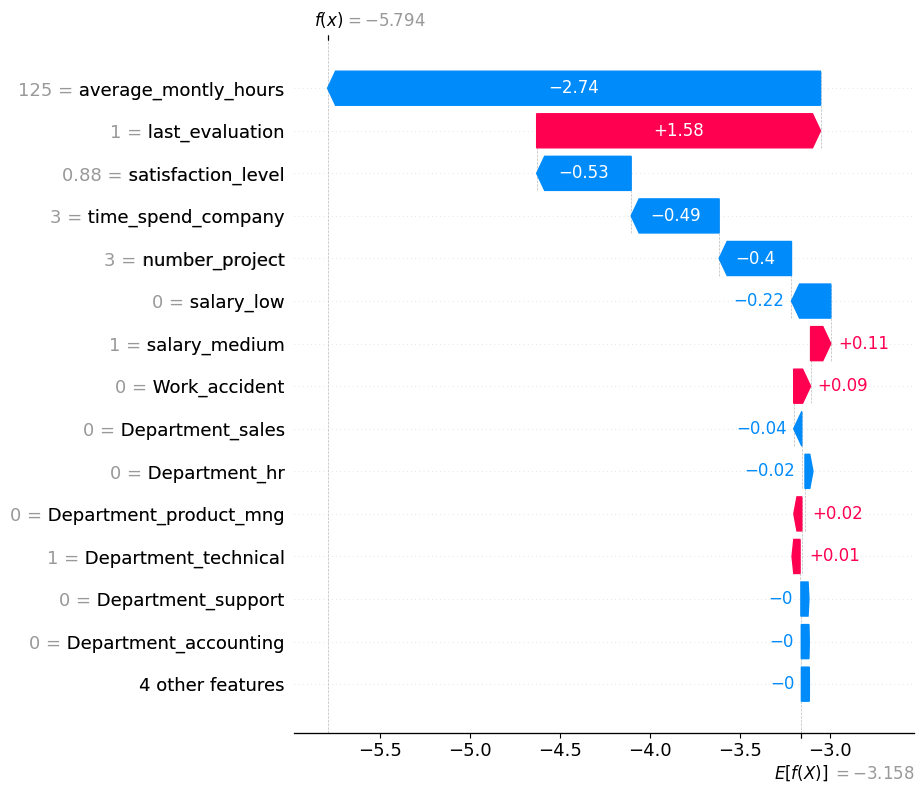

In [16]:
row_index = 0
shap.plots.waterfall(shap_values[row_index], max_display=15)

In [17]:
results = X_test.copy()
results["actual_left"] = y_test.values
results["predicted_probability_left"] = y_prob

top_risk = results.sort_values("predicted_probability_left", ascending=False).head(10)
print(top_risk)

       satisfaction_level  last_evaluation  number_project  \
340                  0.09             0.89             7.0   
12331                0.11             0.85             7.0   
14542                0.11             0.85             7.0   
12517                0.09             0.86             7.0   
1153                 0.10             0.88             7.0   
1228                 0.10             0.85             7.0   
559                  0.11             0.80             7.0   
1963                 0.09             0.89             7.0   
654                  0.10             0.89             7.0   
614                  0.09             0.90             7.0   

       average_montly_hours  time_spend_company  Work_accident  \
340                   308.0                 5.0            0.0   
12331                 302.0                 4.0            0.0   
14542                 302.0                 4.0            0.0   
12517                 309.0                 4.0      

In [18]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_importance.head(15))

                   feature  importance
0       satisfaction_level    0.250259
4       time_spend_company    0.232068
2           number_project    0.145059
1          last_evaluation    0.095107
3     average_montly_hours    0.076466
5            Work_accident    0.042862
16              salary_low    0.026756
17           salary_medium    0.019389
10   Department_management    0.016983
15    Department_technical    0.015125
9            Department_hr    0.014260
14      Department_support    0.013738
12  Department_product_mng    0.012850
13        Department_sales    0.012401
6    promotion_last_5years    0.009098


In [19]:
top_risk_clean = top_risk[[
    "satisfaction_level",
    "number_project",
    "average_montly_hours",
    "time_spend_company",
    "promotion_last_5years",
    "predicted_probability_left"
]]

print(top_risk_clean)

       satisfaction_level  number_project  average_montly_hours  \
340                  0.09             7.0                 308.0   
12331                0.11             7.0                 302.0   
14542                0.11             7.0                 302.0   
12517                0.09             7.0                 309.0   
1153                 0.10             7.0                 300.0   
1228                 0.10             7.0                 310.0   
559                  0.11             7.0                 296.0   
1963                 0.09             7.0                 310.0   
654                  0.10             7.0                 308.0   
614                  0.09             7.0                 296.0   

       time_spend_company  promotion_last_5years  predicted_probability_left  
340                   5.0                    0.0                    0.999929  
12331                 4.0                    0.0                    0.999922  
14542                 4.0